---
# Business Analytics | Final Project
#### 🕺 Clarence Diangco 🕺 John Mark Gerozaga 🕺 Kyer Ivan Jayme 🕺
## Phase 2: Data Profiling & Exploratory Data Analysis (EDA)
---

### 2.1 Setup & Data Loading

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# ── Load ───────────────────────────────────────────────────
df = pd.read_csv('Group_Closer_Dataset.csv', parse_dates=['order_date'])

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1000, 20)


,customer_id,gender,region,age,age_cleaned,age_group,age_missing_flag,age_model,age_treatment_method,product_name,category,unit_price,quantity,total_price,shipping_fee,shipping_status,order_date,year,month,year_month
0,CUST0268,Male,North,NaN,21.0,18-24,1,21,Recovered from same Customer ID,Monitor,Electronics,300.0,5,1500.0,13.31,Returned,2023-12-08,2023,12,2023-12
1,CUST0046,Male,West,22.0,22.0,18-24,0,22,Original,Headphones,Accessories,100.0,2,200.0,6.93,In Transit,2023-04-09,2023,4,2023-04
2,CUST0169,Female,South,54.0,54.0,45-54,0,54,Original,Monitor,Electronics,300.0,1,300.0,11.31,Returned,2023-08-28,2023,8,2023-08
3,CUST0002,Male,North,23.0,23.0,18-24,0,23,Original,Headphones,Accessories,100.0,5,500.0,12.22,Delivered,2023-01-18,2023,1,2023-01
4,CUST0173,Female,South,NaN,65.0,65+,1,65,Recovered from same Customer ID,Laptop,Electronics,1500.0,3,4500.0,5.40,Delivered,2023-01-19,2023,1,2023-01


### 2.2 Initial Inspection

In [153]:
print("shape:", df.shape) ## Number of rows and columns

shape: (1000, 20)


In [154]:
print("=== Data Types & Non-Null Counts ===")
df.info()


=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           1000 non-null   object        
 1   gender                1000 non-null   object        
 2   region                1000 non-null   object        
 3   age                   900 non-null    float64       
 4   age_cleaned           993 non-null    float64       
 5   age_group             1000 non-null   object        
 6   age_missing_flag      1000 non-null   int64         
 7   age_model             1000 non-null   int64         
 8   age_treatment_method  1000 non-null   object        
 9   product_name          1000 non-null   object        
 10  category              1000 non-null   object        
 11  unit_price            1000 non-null   float64       
 12  quantity              1000 non-null   in

In [155]:
print("dTypes:") ## exact data type per column
df.dtypes

dTypes:


customer_id                     object
gender                          object
region                          object
age                            float64
age_cleaned                    float64
age_group                       object
age_missing_flag                 int64
age_model                        int64
age_treatment_method            object
product_name                    object
category                        object
unit_price                     float64
quantity                         int64
total_price                    float64
shipping_fee                   float64
shipping_status                 object
order_date              datetime64[ns]
year                             int64
month                            int64
year_month                      object
dtype: object

In [156]:
print("=== Statistical Summary — Numeric Columns ===")
df.describe().round(2)


=== Statistical Summary — Numeric Columns ===


,age,age_cleaned,age_missing_flag,age_model,unit_price,quantity,total_price,shipping_fee,order_date,year,month
count,900.00,993.00,1000.0,1000.00,1000.00,1000.00,1000.00,1000.00,1000,1000.00,1000.00
mean,46.70,46.68,0.1,46.70,446.63,3.01,1346.60,12.42,2023-07-07 19:30:43.200000,2023.02,6.49
min,18.00,18.00,0.0,18.00,30.00,1.00,30.00,5.00,2023-01-01 00:00:00,2023.00,1.00
25%,35.00,35.00,0.0,35.00,50.00,2.00,200.00,8.56,2023-04-08 00:00:00,2023.00,3.00
50%,49.00,49.00,0.0,49.00,200.00,3.00,600.00,12.32,2023-07-12 12:00:00,2023.00,7.00
75%,59.00,59.00,0.0,59.00,800.00,4.00,1500.00,16.08,2023-10-12 18:00:00,2023.00,10.00
max,69.00,69.00,1.0,69.00,1500.00,5.00,7500.00,19.98,2024-01-03 00:00:00,2024.00,12.00
std,15.01,15.01,0.3,14.96,510.90,1.40,1834.04,4.41,NaN,0.14,3.53


In [157]:
df.describe(include="object") ## Summary of Categorical/text fields

,customer_id,gender,region,age_group,age_treatment_method,product_name,category,shipping_status,year_month
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,292,2,5,7,3,7,3,4,13
top,CUST0052,Male,West,55-64,Original,Monitor,Electronics,In Transit,2023-01
freq,9,524,246,214,900,181,477,329,94


In [158]:
df.head() ## first

,customer_id,gender,region,age,age_cleaned,age_group,age_missing_flag,age_model,age_treatment_method,product_name,category,unit_price,quantity,total_price,shipping_fee,shipping_status,order_date,year,month,year_month
0,CUST0268,Male,North,NaN,21.0,18-24,1,21,Recovered from same Customer ID,Monitor,Electronics,300.0,5,1500.0,13.31,Returned,2023-12-08,2023,12,2023-12
1,CUST0046,Male,West,22.0,22.0,18-24,0,22,Original,Headphones,Accessories,100.0,2,200.0,6.93,In Transit,2023-04-09,2023,4,2023-04
2,CUST0169,Female,South,54.0,54.0,45-54,0,54,Original,Monitor,Electronics,300.0,1,300.0,11.31,Returned,2023-08-28,2023,8,2023-08
3,CUST0002,Male,North,23.0,23.0,18-24,0,23,Original,Headphones,Accessories,100.0,5,500.0,12.22,Delivered,2023-01-18,2023,1,2023-01
4,CUST0173,Female,South,NaN,65.0,65+,1,65,Recovered from same Customer ID,Laptop,Electronics,1500.0,3,4500.0,5.40,Delivered,2023-01-19,2023,1,2023-01


In [159]:
df.tail()

,customer_id,gender,region,age,age_cleaned,age_group,age_missing_flag,age_model,age_treatment_method,product_name,category,unit_price,quantity,total_price,shipping_fee,shipping_status,order_date,year,month,year_month
995,CUST0201,Female,South,49.0,49.0,45-54,0,49,Original,Headphones,Accessories,100.0,1,100.0,17.21,In Transit,2023-01-05,2023,1,2023-01
996,CUST0133,Male,East,47.0,47.0,45-54,0,47,Original,Laptop,Electronics,1500.0,1,1500.0,19.19,Delivered,2023-04-01,2023,4,2023-04
997,CUST0055,Female,North,NaN,45.0,45-54,1,45,Recovered from same Customer ID,Mouse,Accessories,30.0,5,150.0,19.35,Delivered,2023-10-20,2023,10,2023-10
998,CUST0023,Female,South,29.0,29.0,25-34,0,29,Original,Laptop,Electronics,1500.0,5,7500.0,10.36,Returned,2023-01-07,2023,1,2023-01
999,CUST0040,Male,Unknown,29.0,29.0,25-34,0,29,Original,Smartwatch,Wearables,200.0,1,200.0,7.53,Delivered,2023-01-30,2023,1,2023-01


In [160]:
## Validate data type
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

print("Earliest order date:", df["order_date"].min())
print("Latest order date:", df["order_date"].max())
print("Invalid order dates:", df["order_date"].isna().sum())

Earliest order date: 2023-01-01 00:00:00
Latest order date: 2024-01-03 00:00:00
Invalid order dates: 0


The order_date column was converted into datetime format so it can be used for time-based analysis. The dataset covers transactions from January 1, 2023 to January 3, 2024. Any invalid date values were checked using missing-value detection after conversion.

### 2.3 Missing Value Analysis

             Missing Count  Missing %
age                    100       10.0
age_cleaned              7        0.7


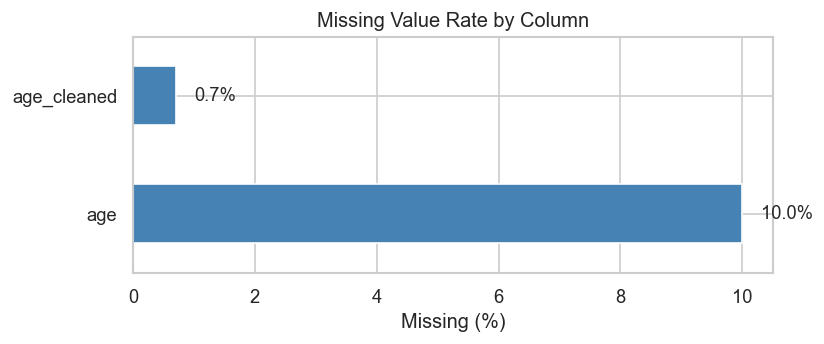

In [161]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

# Visualise
fig, ax = plt.subplots(figsize=(7, 3))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Missing Value Rate by Column')
ax.set_xlabel('Missing (%)')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center')
plt.tight_layout()
plt.show()



Treatment applied:

  • age: The original column was preserved to show the raw missing values.

  • age_cleaned: Missing ages were recovered using the same Customer ID where possible. Seven records remain unresolved and are kept as Unknown for age-based analysis.

  • age_model: Remaining unresolved ages were median-imputed only for predictive modeling.

  • region and shipping_status: Unknown values were retained as valid categories instead of being imputed.
  
  • No rows were deleted during missing value treatment.

In [162]:
print("UNKNOWN AREA: \n")
unknown_cols = ["region", "shipping_status", "age_group"]

for col in unknown_cols:
    print(f"\n{col.upper()}")
    print(df[col].value_counts(dropna=False))

UNKNOWN AREA: 


REGION
region
West       246
South      244
East       231
North      229
Unknown     50
Name: count, dtype: int64

SHIPPING_STATUS
shipping_status
In Transit    329
Delivered     313
Returned      308
Unknown        50
Name: count, dtype: int64

AGE_GROUP
age_group
55-64      214
45-54      200
35-44      190
25-34      150
65+        146
18-24       93
Unknown      7
Name: count, dtype: int64


This is important because Unknown values are intentional categories, not blank values

In [163]:
## Age Treatment Check
age_cols = [
    "age",
    "age_cleaned",
    "age_group",
    "age_missing_flag",
    "age_model",
    "age_treatment_method"
]

df[age_cols].head(15)

,age,age_cleaned,age_group,age_missing_flag,age_model,age_treatment_method
0,NaN,21.0,18-24,1,21,Recovered from same Customer ID
1,22.0,22.0,18-24,0,22,Original
2,54.0,54.0,45-54,0,54,Original
3,23.0,23.0,18-24,0,23,Original
4,NaN,65.0,65+,1,65,Recovered from same Customer ID
5,64.0,64.0,55-64,0,64,Original
6,27.0,27.0,25-34,0,27,Original
7,18.0,18.0,18-24,0,18,Original
8,22.0,22.0,18-24,0,22,Original
9,29.0,29.0,25-34,0,29,Original


In [164]:
df[age_cols].isna().sum()

age                     100
age_cleaned               7
age_group                 0
age_missing_flag          0
age_model                 0
age_treatment_method      0
dtype: int64

In [165]:
df["age_treatment_method"].value_counts(dropna=False)

age_treatment_method
Original                                                      900
Recovered from same Customer ID                                93
Unknown for age analysis; median-imputed for modeling only      7
Name: count, dtype: int64

In [166]:
df["age_group"].value_counts(dropna=False)

age_group
55-64      214
45-54      200
35-44      190
25-34      150
65+        146
18-24       93
Unknown      7
Name: count, dtype: int64

The original age column preserves the raw missing values. Instead of deleting rows with missing age, the dataset uses a transparent age-treatment approach. The age_cleaned column recovers missing ages using the same Customer ID when possible. Remaining unresolved ages are kept as Unknown in age_group for demographic analysis, while age_model is used only for predictive modeling after median imputation.

In [167]:
## MISSING VALUE TREATMENT DECISION TABLE
treatment_plan = pd.DataFrame({
    "Column": ["age", "age_cleaned", "age_group", "age_model", "region", "shipping_status"],
    "Issue": [
        "Original column has missing values",
        "Some ages remain unresolved after Customer ID recovery",
        "Contains Unknown category for unresolved ages",
        "Prepared numeric age column for modeling",
        "Contains Unknown values",
        "Contains Unknown values"
    ],
    "Treatment Decision": [
        "Preserve original values for transparency",
        "Use for EDA; keep remaining missing values unresolved",
        "Use Unknown category for demographic charts",
        "Use median-imputed age only for predictive modeling",
        "Keep Unknown as a valid category; do not impute",
        "Keep Unknown as a valid category; do not impute"
    ],
    "Reason": [
        "The original column documents the raw data condition",
        "Avoids inventing age values for demographic analysis",
        "Allows records to stay in the dataset without fake ages",
        "Predictive models require complete numeric values",
        "Region cannot be reliably inferred from other fields",
        "Shipping status cannot be reliably inferred from other fields"
    ]
})

treatment_plan

,Column,Issue,Treatment Decision,Reason
0,age,Original column has missing values,Preserve original values for transparency,The original column documents the raw data con...
1,age_cleaned,Some ages remain unresolved after Customer ID ...,Use for EDA; keep remaining missing values unr...,Avoids inventing age values for demographic an...
2,age_group,Contains Unknown category for unresolved ages,Use Unknown category for demographic charts,Allows records to stay in the dataset without ...
3,age_model,Prepared numeric age column for modeling,Use median-imputed age only for predictive mod...,Predictive models require complete numeric values
4,region,Contains Unknown values,Keep Unknown as a valid category; do not impute,Region cannot be reliably inferred from other ...
5,shipping_status,Contains Unknown values,Keep Unknown as a valid category; do not impute,Shipping status cannot be reliably inferred fr...


### 2.4 Outlier Detection — IQR Method

Column            Lower Fence   Upper Fence   Outliers
-------------------------------------------------------
age_cleaned             -1.00         95.00          0
unit_price           -1075.00       1925.00          0
quantity                -1.00          7.00          0
total_price          -1750.00       3450.00        124
shipping_fee            -2.71         27.35          0


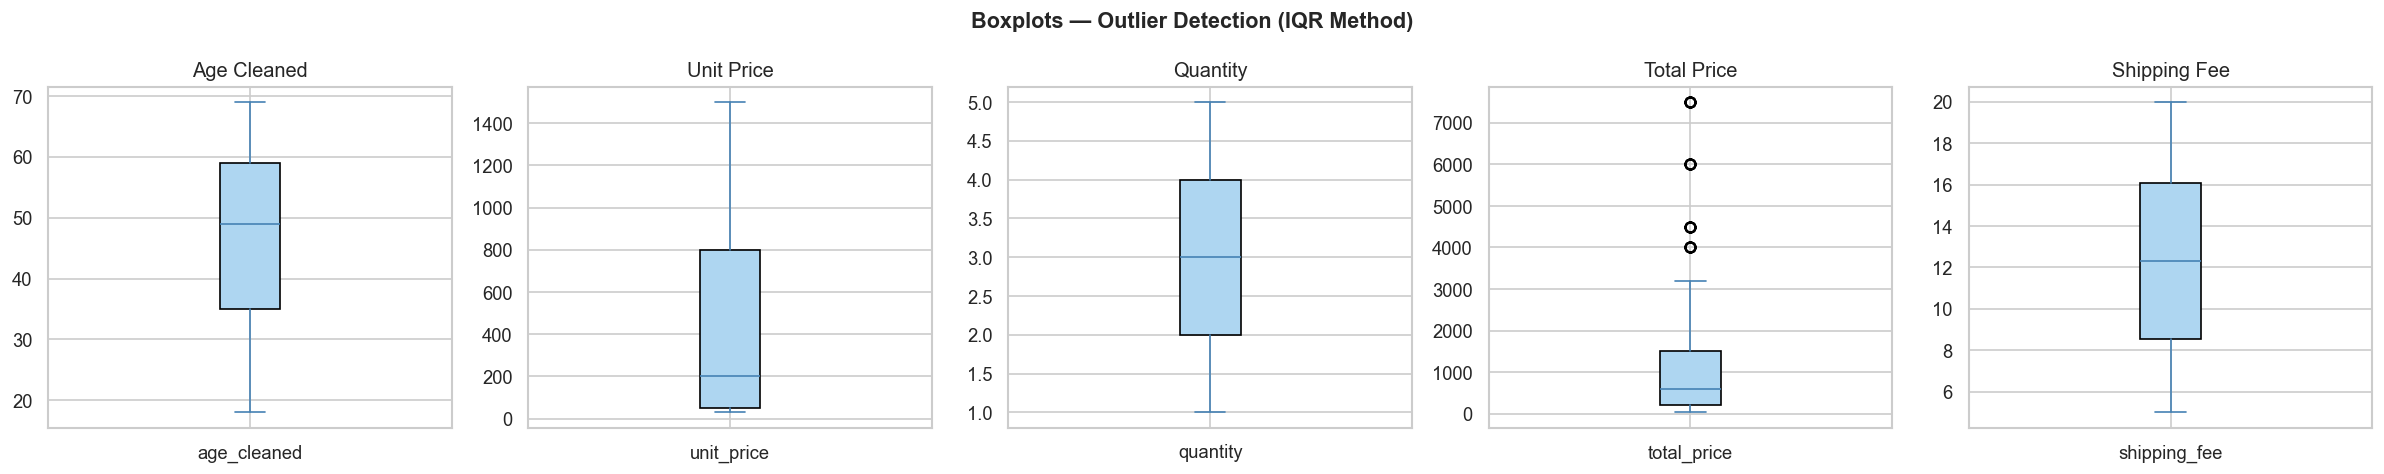


Findings:
  • unit_price has legitimate high-value products (Laptop $1,500; Smartphone $800) — not data errors.
  • total_price outliers reflect bulk high-unit-price orders — plausible business transactions.
  • quantity is bounded 1–5 by business design; no outliers.
  • shipping_fee is tightly distributed ($5–$20); no meaningful outliers.
  → No records removed; outliers are real business variation, not data quality issues.



In [168]:
numeric_cols = ['age_cleaned', 'unit_price', 'quantity', 'total_price', 'shipping_fee']

def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return lower, upper, len(outliers)

print(f"{'Column':<15} {'Lower Fence':>13} {'Upper Fence':>13} {'Outliers':>10}")
print("-" * 55)
for col in numeric_cols:
    lo, hi, n = iqr_outliers(df[col].dropna())
    print(f"{col:<15} {lo:>13.2f} {hi:>13.2f} {n:>10}")

# Boxplots
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 4))

for ax, col in zip(axes, numeric_cols):
    df[col].plot(
        kind="box",
        ax=ax,
        color="steelblue",
        patch_artist=True,
        boxprops=dict(facecolor="#AED6F1")
    )
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")

fig.suptitle("Boxplots — Outlier Detection (IQR Method)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("""
Findings:
  • unit_price has legitimate high-value products (Laptop $1,500; Smartphone $800) — not data errors.
  • total_price outliers reflect bulk high-unit-price orders — plausible business transactions.
  • quantity is bounded 1–5 by business design; no outliers.
  • shipping_fee is tightly distributed ($5–$20); no meaningful outliers.
  → No records removed; outliers are real business variation, not data quality issues.
""")


### 2.5 Distribution Analysis — Numeric Variables

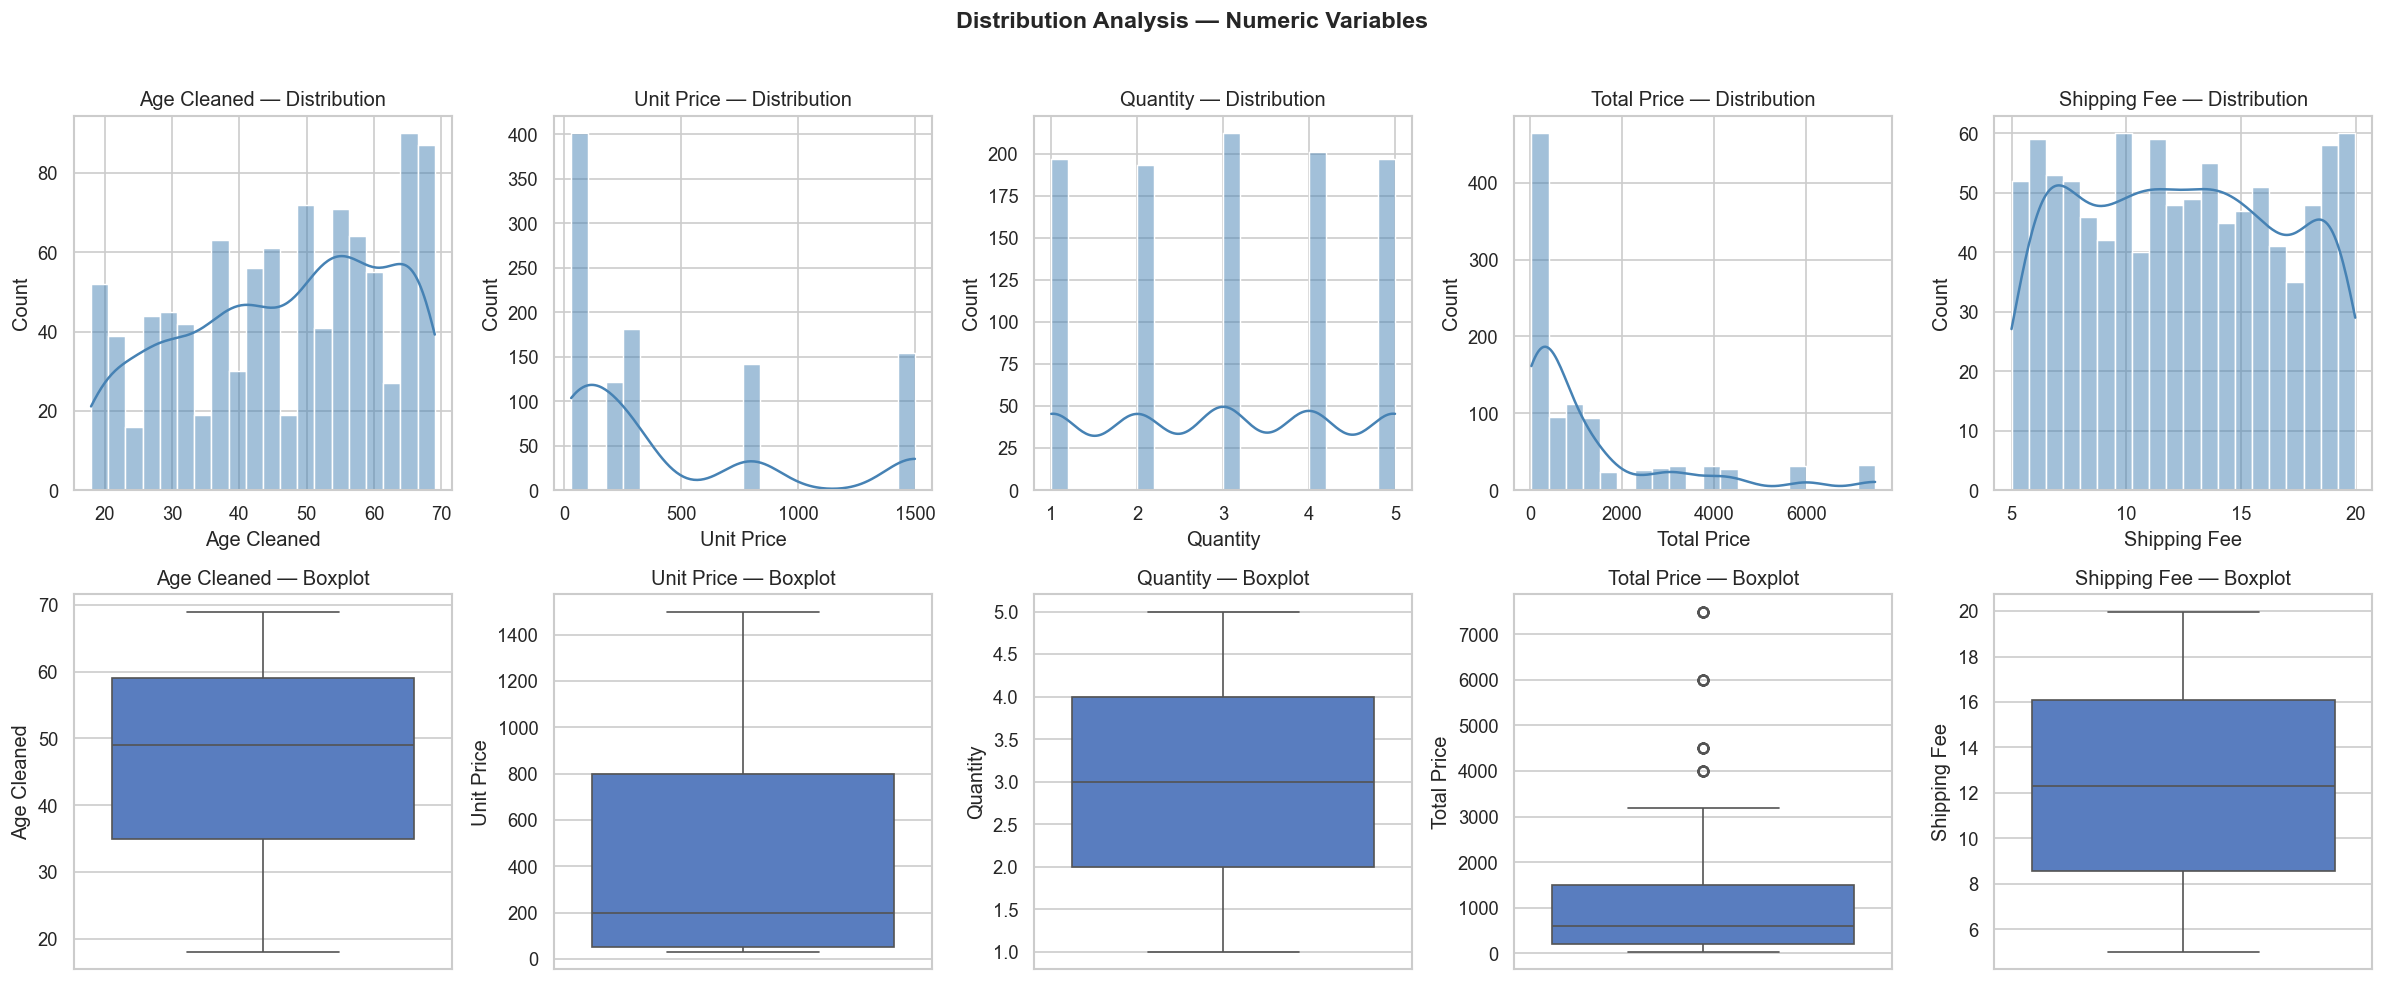

Skewness:
  age_cleaned    : -0.271 (approximately symmetric)
  unit_price     : 1.203 (right-skewed)
  quantity       : -0.014 (approximately symmetric)
  total_price    : 1.927 (right-skewed)
  shipping_fee   : 0.050 (approximately symmetric)


In [169]:
# ── Distribution Analysis — Numeric Variables ─────────────────

fig, axes = plt.subplots(2, len(numeric_cols), figsize=(4 * len(numeric_cols), 8))

for i, col in enumerate(numeric_cols):
    # Histogram + KDE
    ax1 = axes[0, i]
    sns.histplot(df[col].dropna(), kde=True, ax=ax1, bins=20, color="steelblue")
    ax1.set_title(f'{col.replace("_", " ").title()} — Distribution')
    ax1.set_xlabel(col.replace("_", " ").title())
    ax1.set_ylabel("Count")

    # Boxplot
    ax2 = axes[1, i]
    sns.boxplot(y=df[col].dropna(), ax=ax2)
    ax2.set_title(f'{col.replace("_", " ").title()} — Boxplot')
    ax2.set_ylabel(col.replace("_", " ").title())

plt.suptitle('Distribution Analysis — Numeric Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Skewness summary
print("Skewness:")
for col in numeric_cols:
    sk = df[col].skew()
    shape = "right-skewed" if sk > 0.5 else "left-skewed" if sk < -0.5 else "approximately symmetric"
    print(f"  {col:<15}: {sk:.3f} ({shape})")

### 2.6 Correlation Matrix

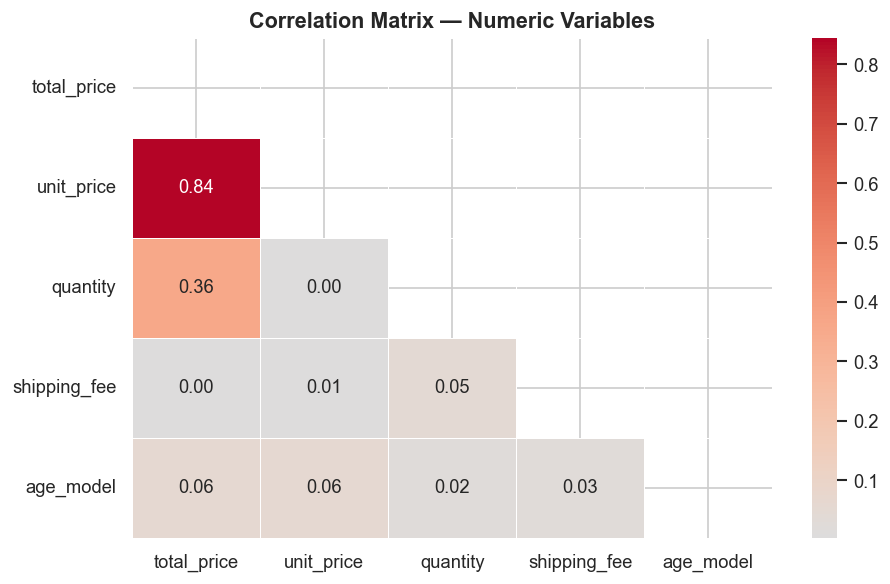

Columns used for correlation: ['total_price', 'unit_price', 'quantity', 'shipping_fee', 'age_model']


In [170]:
# ── Correlation Matrix ───────────────────────────────────────

corr_cols = ['total_price', 'unit_price', 'quantity', 'shipping_fee', 'age_model']
corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Matrix — Numeric Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Columns used for correlation:", corr_cols)

Key correlations:
- unit_price has the strongest positive relationship with total_price, meaning higher-priced products are the main driver of transaction value.
- quantity has a moderate positive relationship with total_price because buying more units increases the order total.
- shipping_fee has a very weak relationship with total_price, suggesting that shipping cost is not strongly tied to transaction value in this dataset.
- age_model also has a very weak relationship with total_price, meaning customer age does not appear to strongly explain order value.

### 2.7 EDA Summary — Key Observations

1. **10% of age data was originally missing.** 100 out of 1,000 records had no age value recorded. A multi-step recovery process was applied — first checking if the same customer appeared elsewhere with a known age, then falling back to imputation. Only 7 records remained unresolved and were tagged as "Unknown."

2. **Outliers exist but are legitimate.** High-value outliers were detected in unit_price and total_price using the IQR method, but upon inspection these reflect real high-ticket purchases like Laptops and Smartphones — not data entry errors. No records were removed as a result.

3. **Shipping fees are surprisingly narrow.** Despite the wide range of products and order sizes, shipping fees consistently fall between $5 and $20 with very little variation. This points to a fixed-rate or weight-band pricing structure rather than fees calculated per order value.

4. **Unit price has the widest spread.** Unit price ranges from as low as $30 (accessories like mice and keyboards) all the way to $1,500 (laptops), reflecting a highly mixed product catalog across very different price tiers.

5. **Region has an 'Unknown' bucket.** A portion of orders could not be attributed to a specific region, grouped under "Unknown." These still represent real revenue and should not be ignored — ideally, the business should investigate why location data is missing at checkout.

6. **Orders are heavily right-skewed.** Most orders are low-to-mid value, with the median sitting well below the mean. A small number of high-quantity, high-price orders create a long right tail that pulls the average up, meaning the "typical" order is actually much smaller than the average suggests.


---
## 📊 Phase 3: Business Questions Analysis


### Q1 — Descriptive Statistics
**Question:** What are the key statistical properties of our numeric sales variables, and are there any notable anomalies or distributional patterns?


In [171]:
from scipy.stats import skew, kurtosis

# Q1 variables based on the business question
# Use age_cleaned instead of age because age_cleaned is the EDA-ready age column.
q1_numeric_cols = [
    "total_price",
    "quantity",
    "unit_price",
    "shipping_fee",
    "age_cleaned"
]

# ── Descriptive Statistics Table ─────────────────────────────

stats_rows = []

for col in q1_numeric_cols:
    s = df[col].dropna()
    
    stats_rows.append({
        "Variable": col.replace("_", " ").title(),
        "Count": int(s.count()),
        "Missing": int(df[col].isna().sum()),
        "Mean": round(s.mean(), 2),
        "Median": round(s.median(), 2),
        "Mode": round(s.mode().iloc[0], 2),
        "Std Dev": round(s.std(), 2),
        "Variance": round(s.var(), 2),
        "Min": round(s.min(), 2),
        "Q1": round(s.quantile(0.25), 2),
        "Q3": round(s.quantile(0.75), 2),
        "Max": round(s.max(), 2),
        "Range": round(s.max() - s.min(), 2),
        "IQR": round(s.quantile(0.75) - s.quantile(0.25), 2),
        "Skewness": round(skew(s), 3),
        "Kurtosis": round(kurtosis(s), 3)
    })

q1_stats_table = pd.DataFrame(stats_rows).set_index("Variable")

display(q1_stats_table)

,Count,Missing,Mean,Median,Mode,Std Dev,Variance,Min,Q1,Q3,Max,Range,IQR,Skewness,Kurtosis
Variable,,,,,,,,,,,,,,,
Total Price,1000,0,1346.60,600.00,200.00,1834.04,3363694.93,30.0,200.00,1500.00,7500.00,7470.00,1300.00,1.924,3.001
Quantity,1000,0,3.01,3.00,3.00,1.40,1.97,1.0,2.00,4.00,5.00,4.00,2.00,-0.014,-1.274
Unit Price,1000,0,446.63,200.00,300.00,510.90,261017.56,30.0,50.00,800.00,1500.00,1470.00,750.00,1.201,-0.033
Shipping Fee,1000,0,12.42,12.32,9.26,4.41,19.47,5.0,8.56,16.08,19.98,14.98,7.51,0.050,-1.201
Age Cleaned,993,7,46.68,49.00,66.00,15.01,225.23,18.0,35.00,59.00,69.00,51.00,24.00,-0.271,-1.088


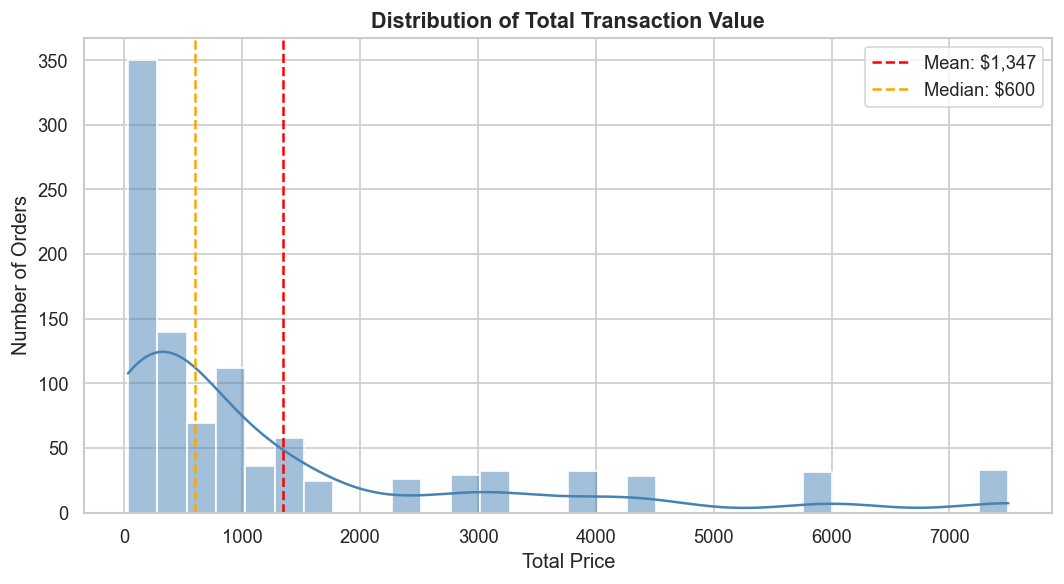

In [172]:
# ── Q1 Visualization: Distribution of Total Transaction Value ──

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="total_price",
    bins=30,
    kde=True,
    ax=ax,
    color="steelblue"
)

mean_total = df["total_price"].mean()
median_total = df["total_price"].median()

ax.axvline(
    mean_total,
    color="red",
    linestyle="--",
    label=f"Mean: ${mean_total:,.0f}"
)

ax.axvline(
    median_total,
    color="orange",
    linestyle="--",
    label=f"Median: ${median_total:,.0f}"
)

ax.set_title("Distribution of Total Transaction Value", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Price")
ax.set_ylabel("Number of Orders")
ax.legend()

plt.tight_layout()
plt.show()

**Business Interpretation:**  
The descriptive statistics show that total transaction value has a wide range compared with the other numeric variables. The distribution of `total_price` is right-skewed, meaning most orders are concentrated at lower to moderate transaction values, while a smaller number of high-value orders pull the average upward. This is expected in an e-commerce dataset because expensive products such as laptops and smartphones can create much higher order totals, especially when customers purchase multiple units.  

Quantity is limited to a small range, while unit price varies more because the dataset contains both low-cost accessories and high-cost electronics. Customer age is analyzed using `age_cleaned`, which preserves valid recovered age values while avoiding the direct use of the original age column that still contains missing values.

### Q2 — Trend Analysis
**Question:** How do monthly total sales and order volume change across the available order period, and which full months show unusually high or low sales?

,year_month,revenue,order_volume,avg_order_value,quantity_sold,is_complete_month
0,2023-01,"$141,360",94,"$1,503.83",298,True
1,2023-02,"$78,910",74,"$1,066.35",201,True
2,2023-03,"$67,660",67,"$1,009.85",210,True
3,2023-04,"$87,840",66,"$1,330.91",189,True
4,2023-05,"$120,080",86,"$1,396.28",267,True
5,2023-06,"$129,450",90,"$1,438.33",274,True
6,2023-07,"$103,160",79,"$1,305.82",226,True
7,2023-08,"$108,050",84,"$1,286.31",239,True
8,2023-09,"$119,490",81,"$1,475.19",240,True
9,2023-10,"$118,240",91,"$1,299.34",276,True


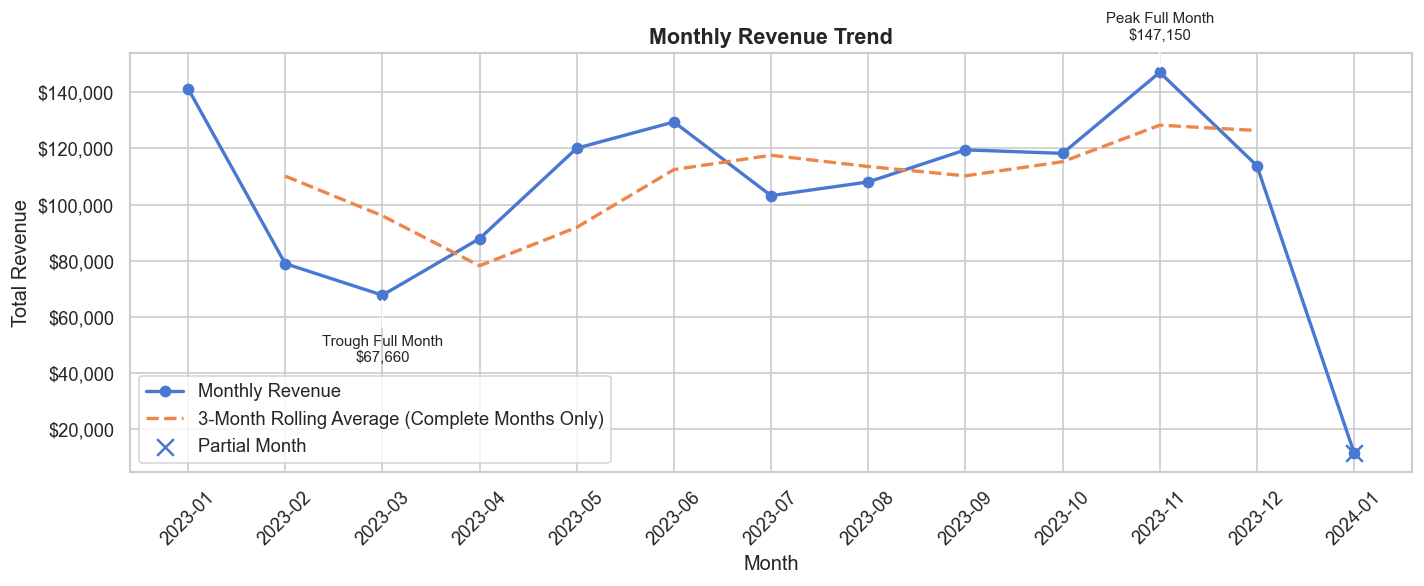

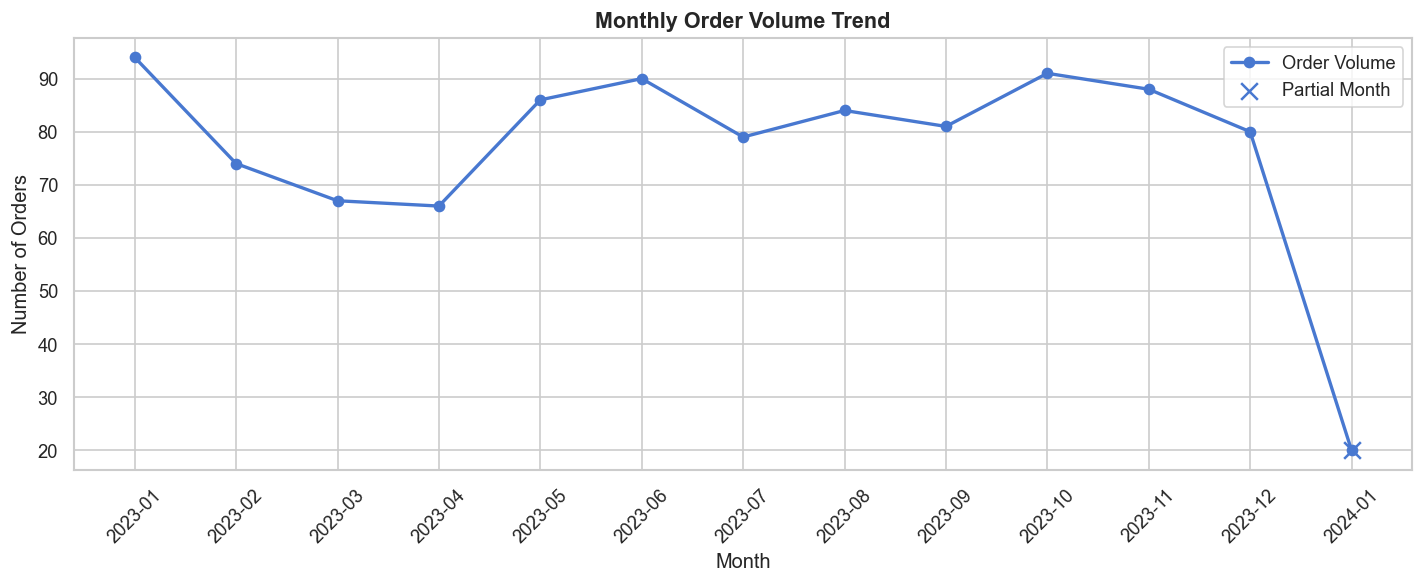

Q2 Trend Summary
Dataset date range: 2023-01-01 to 2024-01-03
Peak full month: 2023-11 with revenue of $147,150
Trough full month: 2023-03 with revenue of $67,660
Partial month(s) excluded from peak/trough detection: 2024-01


In [173]:
# Create a working copy to avoid modifying the original dataset accidentally
q2_df = df.copy()

# Ensure order_date is in datetime format
q2_df["order_date"] = pd.to_datetime(q2_df["order_date"], errors="coerce")

# Create a consistent year_month field from order_date
q2_df["year_month"] = q2_df["order_date"].dt.to_period("M").astype(str)

# Monthly aggregation
monthly = (
    q2_df.groupby("year_month")
         .agg(
             revenue=("total_price", "sum"),
             order_volume=("total_price", "count"),
             avg_order_value=("total_price", "mean"),
             quantity_sold=("quantity", "sum")
         )
         .reset_index()
)

# Convert year_month to datetime for correct sorting and plotting
monthly["period"] = pd.to_datetime(monthly["year_month"])
monthly = monthly.sort_values("period").reset_index(drop=True)

# Identify complete vs partial months
# A month is considered complete only if the dataset covers the full calendar month.
dataset_min_date = q2_df["order_date"].min()
dataset_max_date = q2_df["order_date"].max()

monthly["month_start"] = monthly["period"].dt.to_period("M").dt.start_time
monthly["month_end"] = monthly["period"].dt.to_period("M").dt.end_time.dt.normalize()

monthly["is_complete_month"] = (
    (monthly["month_start"] >= dataset_min_date.to_period("M").start_time) &
    (monthly["month_end"] <= dataset_max_date)
)

# Use only complete months for peak/trough detection
monthly_complete = monthly[monthly["is_complete_month"]].copy()

peak_idx = monthly_complete["revenue"].idxmax()
trough_idx = monthly_complete["revenue"].idxmin()

peak_ym = monthly.loc[peak_idx, "year_month"]
peak_rv = monthly.loc[peak_idx, "revenue"]

trough_ym = monthly.loc[trough_idx, "year_month"]
trough_rv = monthly.loc[trough_idx, "revenue"]

# Rolling average calculated only from complete months
monthly["rolling_avg_3mo"] = np.nan
monthly.loc[monthly["is_complete_month"], "rolling_avg_3mo"] = (
    monthly_complete["revenue"].rolling(window=3, min_periods=2).mean()
)

# Display monthly summary table
monthly_display = monthly[[
    "year_month",
    "revenue",
    "order_volume",
    "avg_order_value",
    "quantity_sold",
    "is_complete_month"
]].copy()

monthly_display["revenue"] = monthly_display["revenue"].map("${:,.0f}".format)
monthly_display["avg_order_value"] = monthly_display["avg_order_value"].map("${:,.2f}".format)

display(monthly_display)

# ── Visualization 1: Monthly Revenue Trend ─────────────────

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly["year_month"],
    monthly["revenue"],
    marker="o",
    linewidth=2,
    label="Monthly Revenue"
)

ax.plot(
    monthly["year_month"],
    monthly["rolling_avg_3mo"],
    linewidth=2,
    linestyle="--",
    label="3-Month Rolling Average (Complete Months Only)"
)

# Annotate peak and trough using only complete months
ax.annotate(
    f"Peak Full Month\n${peak_rv:,.0f}",
    xy=(peak_ym, peak_rv),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center",
    fontsize=9,
    arrowprops=dict(arrowstyle="->")
)

ax.annotate(
    f"Trough Full Month\n${trough_rv:,.0f}",
    xy=(trough_ym, trough_rv),
    xytext=(0, -40),
    textcoords="offset points",
    ha="center",
    fontsize=9,
    arrowprops=dict(arrowstyle="->")
)

# Mark partial months if any exist
partial_months = monthly[~monthly["is_complete_month"]]

for _, row in partial_months.iterrows():
    ax.scatter(
        row["year_month"],
        row["revenue"],
        marker="x",
        s=100,
        label="Partial Month" if row.name == partial_months.index[0] else None
    )

ax.set_title("Monthly Revenue Trend", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

# ── Visualization 2: Monthly Order Volume ─────────────────

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly["year_month"],
    monthly["order_volume"],
    marker="o",
    linewidth=2,
    label="Order Volume"
)

for _, row in partial_months.iterrows():
    ax.scatter(
        row["year_month"],
        row["order_volume"],
        marker="x",
        s=100,
        label="Partial Month" if row.name == partial_months.index[0] else None
    )

ax.set_title("Monthly Order Volume Trend", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

print("Q2 Trend Summary")
print(f"Dataset date range: {dataset_min_date.date()} to {dataset_max_date.date()}")
print(f"Peak full month: {peak_ym} with revenue of ${peak_rv:,.0f}")
print(f"Trough full month: {trough_ym} with revenue of ${trough_rv:,.0f}")

if len(partial_months) > 0:
    partial_list = ", ".join(partial_months["year_month"].tolist())
    print(f"Partial month(s) excluded from peak/trough detection: {partial_list}")

**Business Interpretation:**  
Monthly revenue and order volume fluctuate across the available order period. January 2024 is shown in the chart for transparency, but it is treated as a partial month because the dataset only includes orders up to January 3, 2024. For this reason, January 2024 is excluded from peak and trough detection to avoid misleading comparisons against full months.

Using only complete months, the strongest and weakest sales months are identified more fairly. The trend analysis gives the business a clearer view of monthly sales movement, order activity, and possible periods that may require deeper investigation.

### Q3 — Cross-Tabulation Analysis
**Question:** How does total revenue vary across product categories and customer regions simultaneously?


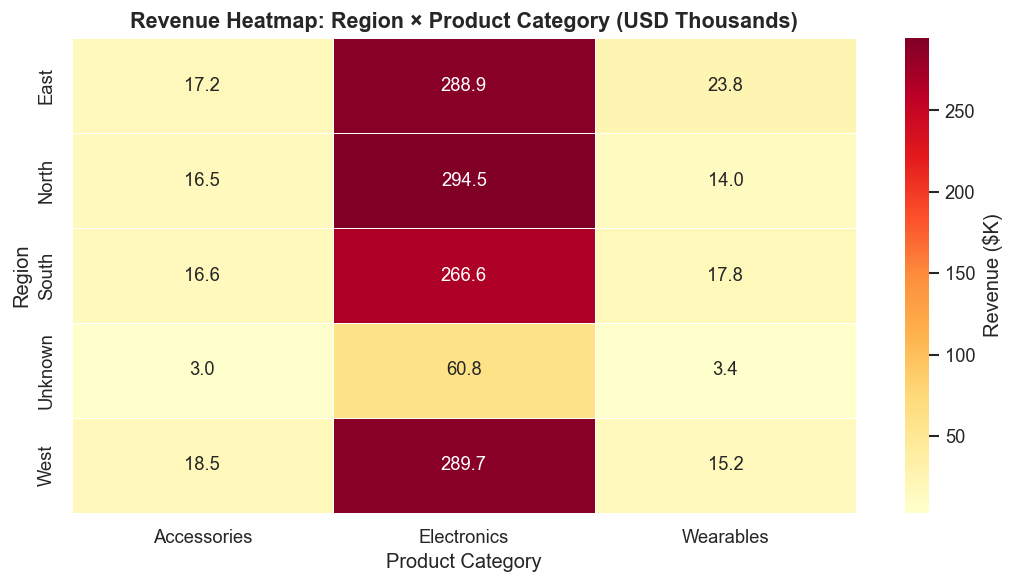

Revenue by Region × Category ($):
category  Accessories  Electronics  Wearables
region                                       
East          17250.0     288900.0    23800.0
North         16490.0     294500.0    14000.0
South         16640.0     266600.0    17800.0
Unknown        3030.0      60800.0     3400.0
West          18490.0     289700.0    15200.0


In [174]:
# ── Crosstab: Category × Region ───────────────────────────
crosstab = df.groupby(['region','category'])['total_price'].sum().unstack(fill_value=0)
crosstab_k = (crosstab / 1000).round(1)  # in $K

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(crosstab_k, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Revenue ($K)'})
ax.set_title('Revenue Heatmap: Region × Product Category (USD Thousands)', fontsize=13, fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()

print("Revenue by Region × Category ($):")
print(crosstab.to_string())



Takeaway: Electronics dominates revenue in all regions because it contains higher-priced products such as laptops, smartphones, and monitors. Accessories and Wearables contribute lower revenue, likely because they have lower unit prices and smaller transaction values. The Unknown region contributes meaningful sales and should be treated as a data-quality category that needs proper attribution.

### Q4 — Drill-Down Analysis
**Question:** Starting from total sales, how does performance break down by region, category, and product-level performance?


In [175]:
import plotly.express as px

# Overall sales benchmark
overall_sales = df["total_price"].sum()
overall_orders = df["total_price"].count()
overall_quantity = df["quantity"].sum()

print("Overall Sales Summary")
print(f"Total Sales: ${overall_sales:,.2f}")
print(f"Total Orders: {overall_orders:,}")
print(f"Total Quantity Sold: {overall_quantity:,}")

Overall Sales Summary
Total Sales: $1,346,600.00
Total Orders: 1,000
Total Quantity Sold: 3,008


In [176]:
# ── Region-Level Summary ─────────────────────────────────────

region_summary = (
    df.groupby("region", as_index=False)
      .agg(
          total_sales=("total_price", "sum"),
          order_count=("total_price", "count"),
          quantity_sold=("quantity", "sum"),
          avg_order_value=("total_price", "mean")
      )
      .sort_values("total_sales", ascending=False)
)

region_summary["sales_share_pct"] = (
    region_summary["total_sales"] / overall_sales * 100
).round(2)

display(region_summary)

,region,total_sales,order_count,quantity_sold,avg_order_value,sales_share_pct
0,East,329950.0,231,715,1428.354978,24.50
1,North,324990.0,229,702,1419.170306,24.13
4,West,323390.0,246,733,1314.593496,24.02
2,South,301040.0,244,726,1233.770492,22.36
3,Unknown,67230.0,50,132,1344.600000,4.99


In [177]:
# ── Region → Category Summary ────────────────────────────────

region_category_summary = (
    df.groupby(["region", "category"], as_index=False)
      .agg(
          total_sales=("total_price", "sum"),
          order_count=("total_price", "count"),
          quantity_sold=("quantity", "sum"),
          avg_order_value=("total_price", "mean")
      )
      .sort_values(["region", "total_sales"], ascending=[True, False])
)

region_category_summary["sales_share_pct"] = (
    region_category_summary["total_sales"] / overall_sales * 100
).round(2)

display(region_category_summary)

,region,category,total_sales,order_count,quantity_sold,avg_order_value,sales_share_pct
1,East,Electronics,288900.0,108,326,2675.000000,21.45
2,East,Wearables,23800.0,34,119,700.000000,1.77
0,East,Accessories,17250.0,89,270,193.820225,1.28
4,North,Electronics,294500.0,113,344,2606.194690,21.87
3,North,Accessories,16490.0,89,288,185.280899,1.22
5,North,Wearables,14000.0,27,70,518.518519,1.04
7,South,Electronics,266600.0,119,346,2240.336134,19.80
8,South,Wearables,17800.0,29,89,613.793103,1.32
6,South,Accessories,16640.0,96,291,173.333333,1.24
10,Unknown,Electronics,60800.0,21,64,2895.238095,4.52


In [178]:
# ── Region → Category → Product Summary ──────────────────────

q4_df = (
    df.groupby(["region", "category", "product_name"], as_index=False)
      .agg(
          total_sales=("total_price", "sum"),
          order_count=("total_price", "count"),
          quantity_sold=("quantity", "sum"),
          avg_order_value=("total_price", "mean")
      )
)

q4_df["sales_share_pct"] = (
    q4_df["total_sales"] / overall_sales * 100
).round(2)

q4_df = q4_df.sort_values("total_sales", ascending=False)

display(q4_df.head(15))

,region,category,product_name,total_sales,order_count,quantity_sold,avg_order_value,sales_share_pct
10,North,Electronics,Laptop,178500.0,39,119,4576.923077,13.26
31,West,Electronics,Laptop,172500.0,41,115,4207.317073,12.81
3,East,Electronics,Laptop,169500.0,35,113,4842.857143,12.59
17,South,Electronics,Laptop,141000.0,32,94,4406.250000,10.47
5,East,Electronics,Smartphone,88800.0,33,111,2690.909091,6.59
33,West,Electronics,Smartphone,84800.0,33,106,2569.696970,6.30
19,South,Electronics,Smartphone,80000.0,35,100,2285.714286,5.94
12,North,Electronics,Smartphone,77600.0,31,97,2503.225806,5.76
18,South,Electronics,Monitor,45600.0,52,152,876.923077,3.39
11,North,Electronics,Monitor,38400.0,43,128,893.023256,2.85


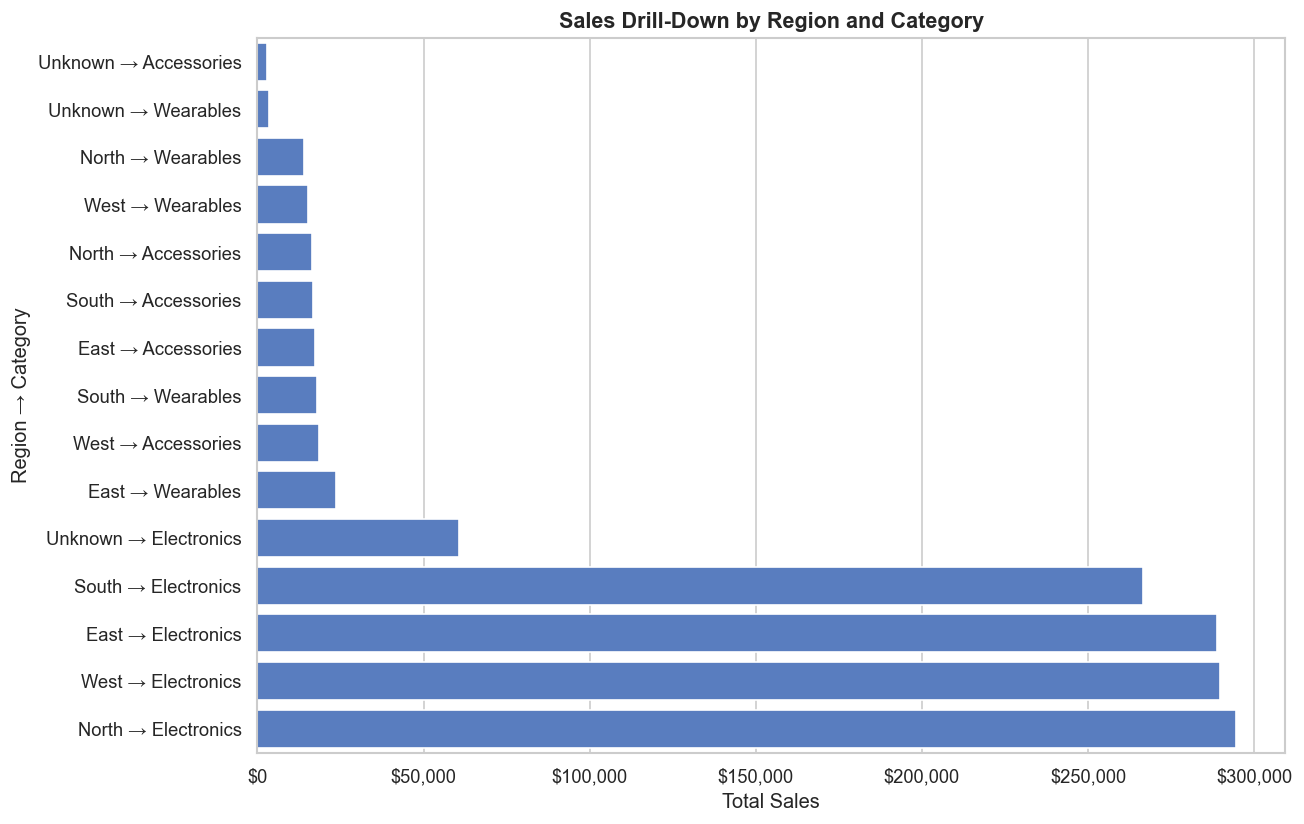

In [179]:
# ── Visualization 1: Hierarchical Bar Chart ──────────────────
# This chart shows the Region → Category drill-down using total sales.

region_category_plot = region_category_summary.copy()

# Create a readable hierarchy label
region_category_plot["region_category"] = (
    region_category_plot["region"] + " → " + region_category_plot["category"]
)

# Sort for cleaner visual output
region_category_plot = region_category_plot.sort_values("total_sales", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=region_category_plot,
    x="total_sales",
    y="region_category",
    ax=ax
)

ax.set_title(
    "Sales Drill-Down by Region and Category",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Total Sales")
ax.set_ylabel("Region → Category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

In [180]:
# ── Visualization 2: Interactive Treemap ─────────────────────
# This treemap shows the full drill-down path:
# Region → Category → Product

fig = px.treemap(
    q4_df,
    path=["region", "category", "product_name"],
    values="total_sales",
    color="total_sales",
    title="Sales Drill-Down: Region → Category → Product",
    hover_data={
        "total_sales": ":,.2f",
        "order_count": True,
        "quantity_sold": True,
        "avg_order_value": ":,.2f",
        "sales_share_pct": ":.2f"
    }
)

fig.update_traces(
    textinfo="label+value+percent parent",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Total Sales: $%{value:,.2f}<br>"
        "Percentage of Parent: %{percentParent:.2%}<br>"
        "Percentage of Total: %{percentRoot:.2%}<br>"
        "<extra></extra>"
    )
)

fig.update_layout(
    title_font_size=18,
    margin=dict(t=60, l=20, r=20, b=20)
)

fig.show()

In [181]:
# ── Top Sales Drivers ────────────────────────────────────────

top_region = region_summary.iloc[0]

top_region_category = region_category_summary.sort_values(
    "total_sales", ascending=False
).iloc[0]

top_product_segment = q4_df.iloc[0]

print("Top Drill-Down Findings")
print(f"Top Region: {top_region['region']} with ${top_region['total_sales']:,.2f} in sales")
print(
    f"Top Region-Category Combination: {top_region_category['region']} → "
    f"{top_region_category['category']} with ${top_region_category['total_sales']:,.2f} in sales"
)
print(
    f"Top Region-Category-Product Segment: {top_product_segment['region']} → "
    f"{top_product_segment['category']} → {top_product_segment['product_name']} "
    f"with ${top_product_segment['total_sales']:,.2f} in sales"
)

Top Drill-Down Findings
Top Region: East with $329,950.00 in sales
Top Region-Category Combination: North → Electronics with $294,500.00 in sales
Top Region-Category-Product Segment: North → Electronics → Laptop with $178,500.00 in sales


**Business Interpretation:**  
The drill-down analysis shows how total sales can be broken down from the overall business level into region, category, and product-level performance. The hierarchical bar chart provides a clear static view of which region-category combinations generate the highest sales, while the treemap provides a deeper interactive view that breaks sales down further into individual products.

This is useful for business decision-making because it identifies the specific segments responsible for revenue. If a region performs strongly, the drill-down helps reveal whether that performance is mainly caused by a high-performing category or by specific products within that category. This can support better inventory planning, regional sales strategy, and product prioritization.

### Q5 — Correlation & Predictive Analysis
**Question:** Which numeric variables most predict total order value, and can a simple model quantify that relationship?


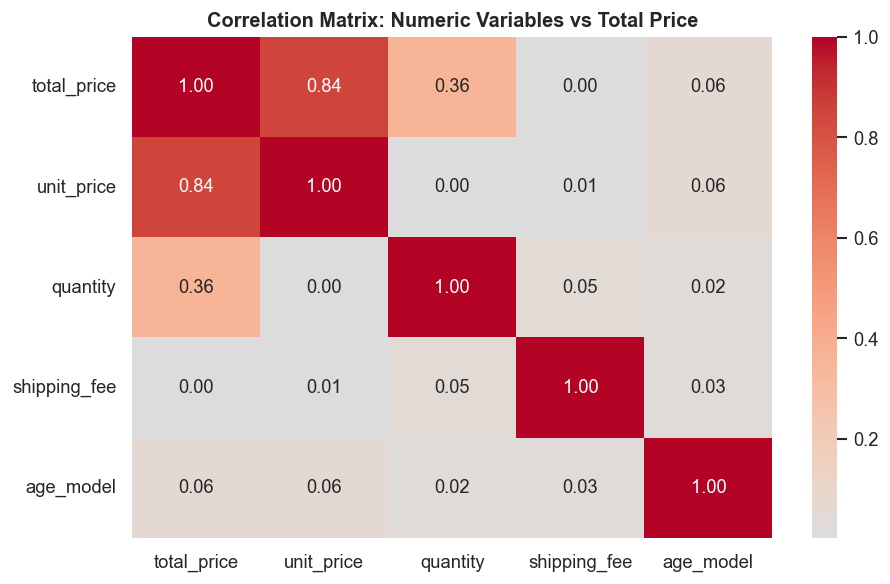

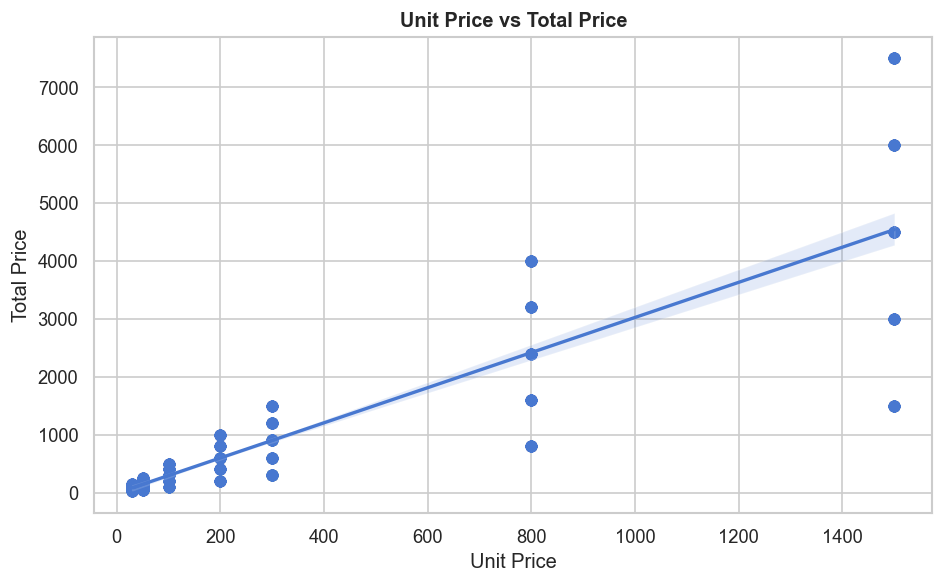

Model Results
R² Score: 0.8448
Mean Absolute Error: 571.32


,Variable,Coefficient
1,quantity,469.618007
0,unit_price,3.000583
3,age_model,0.039458
2,shipping_fee,-7.698935


In [182]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Variables for Q5
q5_cols = ["total_price", "unit_price", "quantity", "shipping_fee", "age_model"]
q5_df = df[q5_cols].dropna()

# 1) Correlation matrix
corr_q5 = q5_df.corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_q5, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Numeric Variables vs Total Price", fontweight="bold")
plt.tight_layout()
plt.show()

# 2) Scatter plot with regression line
# Unit price is used because it is expected to be the strongest predictor.
plt.figure(figsize=(8, 5))
sns.regplot(
    data=q5_df,
    x="unit_price",
    y="total_price",
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
)

plt.title("Unit Price vs Total Price", fontweight="bold")
plt.xlabel("Unit Price")
plt.ylabel("Total Price")
plt.tight_layout()
plt.show()

# 3) Simple linear regression model
X = q5_df[["unit_price", "quantity", "shipping_fee", "age_model"]]
y = q5_df["total_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

coef_table = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print("Model Results")
print("R² Score:", round(r2, 4))
print("Mean Absolute Error:", round(mae, 2))

display(coef_table)

**Business Interpretation:**  
The correlation matrix shows that `unit_price` has the strongest relationship with `total_price`, followed by `quantity`. This is expected because total transaction value is directly affected by the item price and the number of units purchased. The scatter plot also shows a clear positive relationship between unit price and total price.

The regression model uses `unit_price`, `quantity`, `shipping_fee`, and `age_model` to explain total transaction value. The result should be interpreted as an explanatory model rather than an advanced forecasting model because `total_price` is mathematically related to `unit_price` and `quantity`. From a business perspective, this suggests that sales value is mainly product-driven, while shipping fee and customer age have weaker influence.

### Ad Hoc Q6 — Follow-Up from Q2 (Trend Analysis)
**Triggered by:** The monthly trend revealed a notable revenue trough. This question investigates which product category drove that dip, and whether it recovered in subsequent months.

**Question:** 


Ad Hoc Q6 Month Selection
Lowest full month: 2023-03 with revenue of $67,660
Highest full month: 2023-11 with revenue of $147,150
Partial month(s) excluded from this analysis: 2024-01


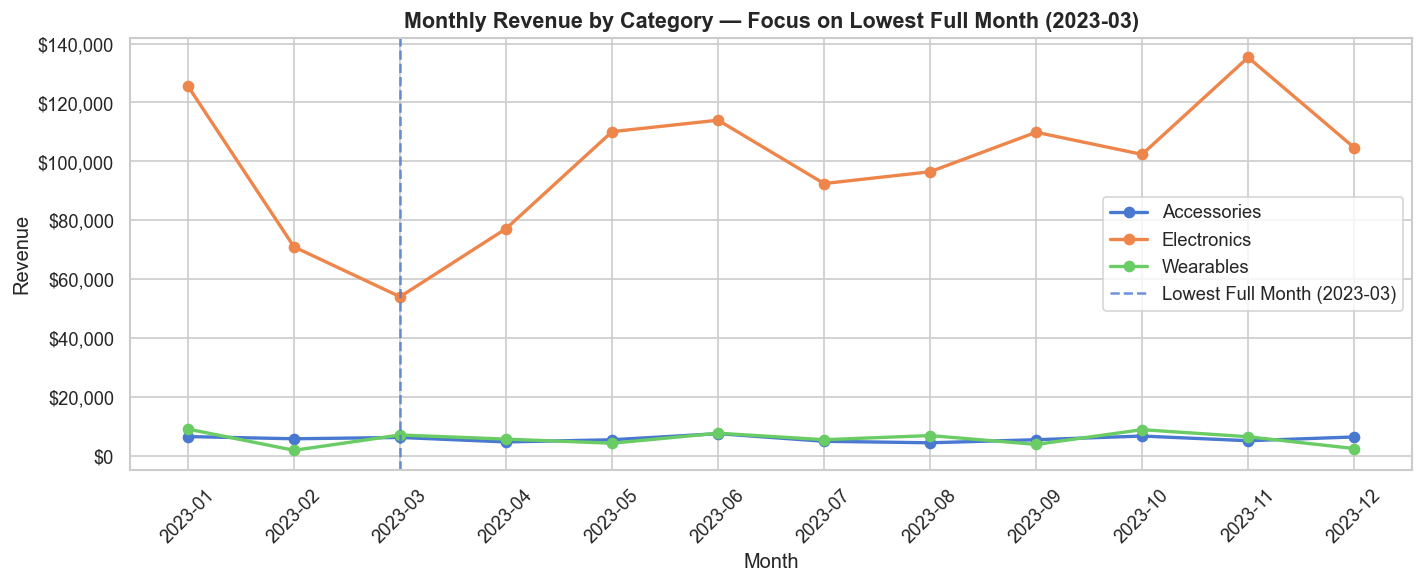

,category,total_sales,sales_share_pct,order_count,avg_order_value,quantity_sold,avg_monthly_sales,difference_vs_avg,pct_difference_vs_avg
0,Electronics,"$54,100.00",79.96,27,"$2,003.70",83,"$99,433.33","$-45,333.33",-45.59
1,Wearables,"$7,200.00",10.64,9,$800.00,36,"$5,933.33","$1,266.67",21.35
2,Accessories,"$6,360.00",9.40,31,$205.16,91,"$5,901.67",$458.33,7.77


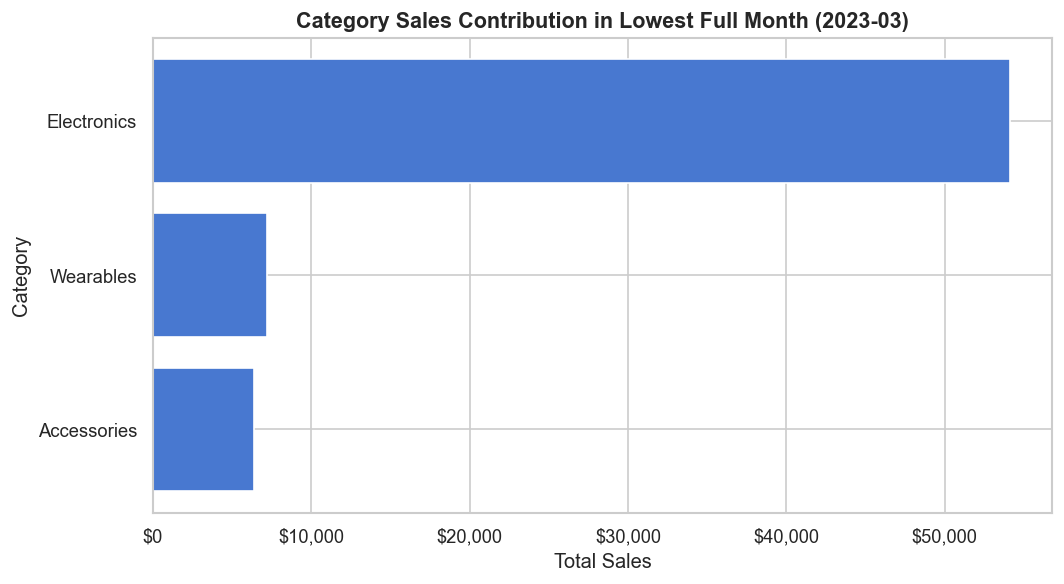

,product_name,category,total_sales,order_count,avg_order_value,quantity_sold,sales_share_pct
2,Laptop,Electronics,24000.0,6,4000.000000,16,35.47
5,Smartphone,Electronics,16000.0,7,2285.714286,20,23.65
3,Monitor,Electronics,14100.0,14,1007.142857,47,20.84
6,Smartwatch,Wearables,7200.0,9,800.000000,36,10.64
0,Headphones,Accessories,4300.0,14,307.142857,43,6.36
1,Keyboard,Accessories,1550.0,10,155.000000,31,2.29
4,Mouse,Accessories,510.0,7,72.857143,17,0.75


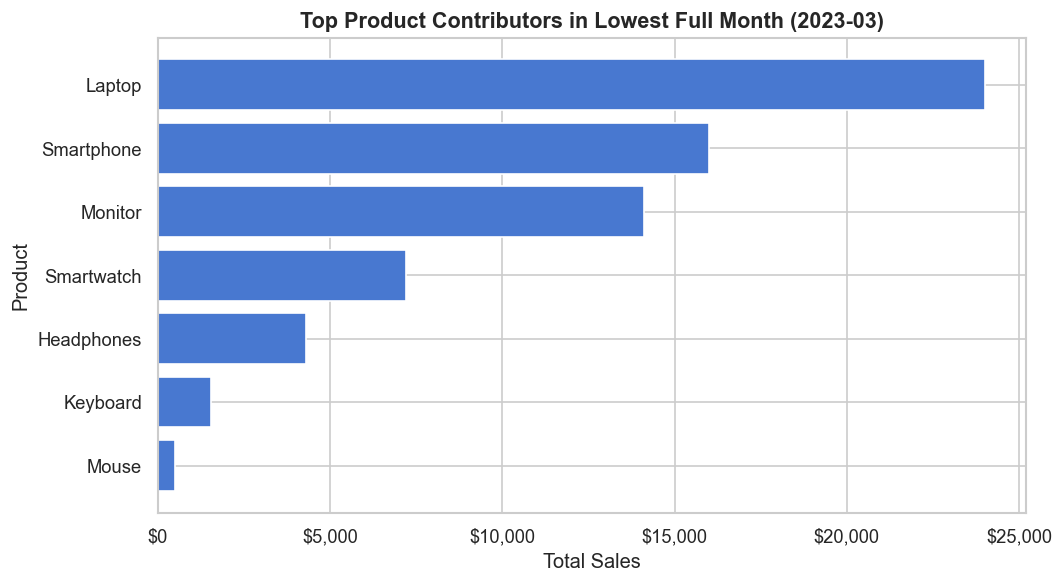

,region,total_sales,order_count,avg_order_value,quantity_sold,sales_share_pct
2,South,24700.0,22,1122.727273,65,36.51
0,East,17510.0,12,1459.166667,43,25.88
4,West,12420.0,17,730.588235,51,18.36
1,North,11100.0,13,853.846154,41,16.41
3,Unknown,1930.0,3,643.333333,10,2.85


In [183]:
# Create a working copy
q6_df = df.copy()

# Ensure order_date and year_month are properly formatted
q6_df["order_date"] = pd.to_datetime(q6_df["order_date"], errors="coerce")
q6_df["year_month"] = q6_df["order_date"].dt.to_period("M").astype(str)

# Monthly revenue summary
monthly_raw = (
    q6_df.groupby("year_month")
         .agg(
             revenue=("total_price", "sum"),
             order_volume=("total_price", "count"),
             avg_order_value=("total_price", "mean"),
             quantity_sold=("quantity", "sum")
         )
         .reset_index()
)

monthly_raw["period"] = pd.to_datetime(monthly_raw["year_month"])
monthly_raw = monthly_raw.sort_values("period").reset_index(drop=True)

# Identify complete vs partial months
dataset_min_date = q6_df["order_date"].min()
dataset_max_date = q6_df["order_date"].max()

monthly_raw["month_start"] = monthly_raw["period"].dt.to_period("M").dt.start_time
monthly_raw["month_end"] = monthly_raw["period"].dt.to_period("M").dt.end_time.dt.normalize()

monthly_raw["is_complete_month"] = (
    (monthly_raw["month_start"] >= dataset_min_date.to_period("M").start_time) &
    (monthly_raw["month_end"] <= dataset_max_date)
)

# Exclude partial months from trough detection
monthly_complete = monthly_raw[monthly_raw["is_complete_month"]].copy()

trough_row = monthly_complete.loc[monthly_complete["revenue"].idxmin()]
trough_month = trough_row["year_month"]
trough_revenue = trough_row["revenue"]

peak_row = monthly_complete.loc[monthly_complete["revenue"].idxmax()]
peak_month = peak_row["year_month"]
peak_revenue = peak_row["revenue"]

print("Ad Hoc Q6 Month Selection")
print(f"Lowest full month: {trough_month} with revenue of ${trough_revenue:,.0f}")
print(f"Highest full month: {peak_month} with revenue of ${peak_revenue:,.0f}")

partial_months = monthly_raw[~monthly_raw["is_complete_month"]]["year_month"].tolist()
if partial_months:
    print(f"Partial month(s) excluded from this analysis: {', '.join(partial_months)}")

# ── Category breakdown across complete months ───────────────

cat_monthly = (
    q6_df.groupby(["year_month", "category"])
         .agg(
             total_sales=("total_price", "sum"),
             order_count=("total_price", "count"),
             avg_order_value=("total_price", "mean"),
             quantity_sold=("quantity", "sum")
         )
         .reset_index()
)

cat_monthly = cat_monthly.merge(
    monthly_raw[["year_month", "is_complete_month"]],
    on="year_month",
    how="left"
)

cat_monthly_complete = cat_monthly[cat_monthly["is_complete_month"]].copy()

# Visualization: Monthly revenue by category, complete months only
fig, ax = plt.subplots(figsize=(12, 5))

for cat, grp in cat_monthly_complete.groupby("category"):
    grp = grp.sort_values("year_month")
    ax.plot(
        grp["year_month"],
        grp["total_sales"],
        marker="o",
        linewidth=2,
        label=cat
    )

ax.axvline(
    x=trough_month,
    linestyle="--",
    alpha=0.8,
    label=f"Lowest Full Month ({trough_month})"
)

ax.set_title(
    f"Monthly Revenue by Category — Focus on Lowest Full Month ({trough_month})",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

# ── Category contribution in the trough month ───────────────

trough_category = (
    cat_monthly_complete[cat_monthly_complete["year_month"] == trough_month]
    .copy()
    .sort_values("total_sales", ascending=False)
)

trough_category["sales_share_pct"] = (
    trough_category["total_sales"] / trough_category["total_sales"].sum() * 100
).round(2)

# Compare trough month category sales against each category's complete-month average
category_avg = (
    cat_monthly_complete.groupby("category")
    .agg(avg_monthly_sales=("total_sales", "mean"))
    .reset_index()
)

trough_category = trough_category.merge(category_avg, on="category", how="left")

trough_category["difference_vs_avg"] = (
    trough_category["total_sales"] - trough_category["avg_monthly_sales"]
)

trough_category["pct_difference_vs_avg"] = (
    trough_category["difference_vs_avg"] / trough_category["avg_monthly_sales"] * 100
).round(2)

trough_category_display = trough_category[[
    "category",
    "total_sales",
    "sales_share_pct",
    "order_count",
    "avg_order_value",
    "quantity_sold",
    "avg_monthly_sales",
    "difference_vs_avg",
    "pct_difference_vs_avg"
]].copy()

money_cols = [
    "total_sales",
    "avg_order_value",
    "avg_monthly_sales",
    "difference_vs_avg"
]

for col in money_cols:
    trough_category_display[col] = trough_category_display[col].map("${:,.2f}".format)

display(trough_category_display)

# Visualization: Category contribution in trough month
fig, ax = plt.subplots(figsize=(9, 5))

trough_category_plot = trough_category.sort_values("total_sales", ascending=True)

ax.barh(
    trough_category_plot["category"],
    trough_category_plot["total_sales"]
)

ax.set_title(
    f"Category Sales Contribution in Lowest Full Month ({trough_month})",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Total Sales")
ax.set_ylabel("Category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

# ── Product contribution in the trough month ────────────────

trough_product = (
    q6_df[q6_df["year_month"] == trough_month]
    .groupby(["product_name", "category"])
    .agg(
        total_sales=("total_price", "sum"),
        order_count=("total_price", "count"),
        avg_order_value=("total_price", "mean"),
        quantity_sold=("quantity", "sum")
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
)

trough_product["sales_share_pct"] = (
    trough_product["total_sales"] / trough_product["total_sales"].sum() * 100
).round(2)

display(trough_product.head(10))

# Visualization: Top products in trough month
top_trough_products = trough_product.head(10).sort_values("total_sales", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    top_trough_products["product_name"],
    top_trough_products["total_sales"]
)

ax.set_title(
    f"Top Product Contributors in Lowest Full Month ({trough_month})",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Total Sales")
ax.set_ylabel("Product")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

# ── Region contribution in the trough month ─────────────────

trough_region = (
    q6_df[q6_df["year_month"] == trough_month]
    .groupby("region")
    .agg(
        total_sales=("total_price", "sum"),
        order_count=("total_price", "count"),
        avg_order_value=("total_price", "mean"),
        quantity_sold=("quantity", "sum")
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
)

trough_region["sales_share_pct"] = (
    trough_region["total_sales"] / trough_region["total_sales"].sum() * 100
).round(2)

display(trough_region)

**Business Interpretation:**  
The ad hoc analysis focuses on the lowest full sales month instead of January 2024, because January 2024 is only a partial month in the dataset. This prevents the analysis from incorrectly treating incomplete data as a true monthly sales decline.

By breaking down the lowest full month by category, product, and region, the business can identify which segments contributed most to the weaker sales performance. The category comparison against average monthly sales is especially useful because it shows whether a category was unusually below its normal monthly level. This helps the business determine whether the low month was mainly caused by weaker demand in a major category, fewer high-value product purchases, or lower activity in specific regions.

### Ad Hoc Q7 — Follow-Up from Q3 (Cross-Tabulation)
**Triggered by:** The region-category heatmap showed that some region-category combinations generate much higher sales than others. This follow-up investigates the strongest region-category segment and identifies which products explain its performance.

**Question:** For the strongest region-category sales combination, is performance mainly driven by higher order count, higher average transaction value, or specific products?


Top Region-Category Segment:


,region,category,total_sales,order_count,avg_order_value,quantity_sold
4,North,Electronics,294500.0,113,2606.19469,344


,product_name,total_sales,order_count,avg_order_value,quantity_sold,sales_share_pct
0,Laptop,178500.0,39,4576.923077,119,60.61
2,Smartphone,77600.0,31,2503.225806,97,26.35
1,Monitor,38400.0,43,893.023256,128,13.04


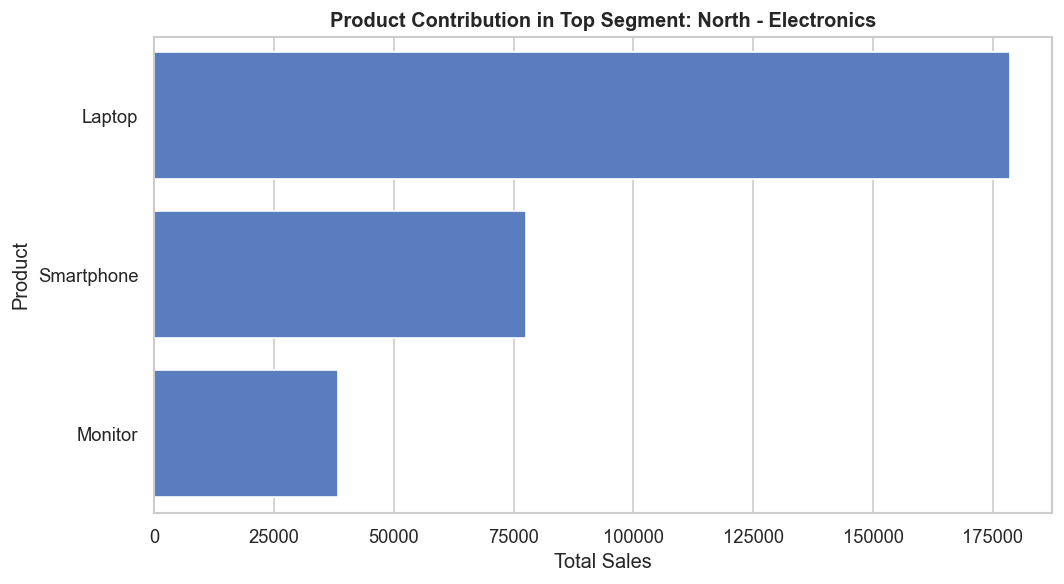

In [184]:
# Exclude Unknown region because it is not useful for regional business decisions
q7_df = df[df["region"] != "Unknown"].copy()

# Find the strongest region-category combination by total sales
region_category = (
    q7_df.groupby(["region", "category"])
    .agg(
        total_sales=("total_price", "sum"),
        order_count=("customer_id", "count"),
        avg_order_value=("total_price", "mean"),
        quantity_sold=("quantity", "sum")
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
)

top_segment = region_category.iloc[0]

top_region = top_segment["region"]
top_category = top_segment["category"]

print("Top Region-Category Segment:")
display(top_segment.to_frame().T)

# Product breakdown inside the top region-category segment
top_segment_products = (
    q7_df[
        (q7_df["region"] == top_region) &
        (q7_df["category"] == top_category)
    ]
    .groupby("product_name")
    .agg(
        total_sales=("total_price", "sum"),
        order_count=("customer_id", "count"),
        avg_order_value=("total_price", "mean"),
        quantity_sold=("quantity", "sum")
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
)

top_segment_products["sales_share_pct"] = (
    top_segment_products["total_sales"] /
    top_segment_products["total_sales"].sum() * 100
).round(2)

display(top_segment_products)

# Visualization
plt.figure(figsize=(9, 5))

sns.barplot(
    data=top_segment_products,
    x="total_sales",
    y="product_name"
)

plt.title(
    f"Product Contribution in Top Segment: {top_region} - {top_category}",
    fontweight="bold"
)
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

**Business Interpretation:**  
The analysis identifies the strongest region-category combination based on total sales, then breaks that segment down by product. This helps explain whether the segment performs well because of many orders, higher average transaction value, or strong sales from specific products.

The product contribution chart shows which products are responsible for most of the sales in the top segment. If one product has a much larger sales share, the business can treat it as the main revenue driver for that region-category combination. This insight can support product prioritization, regional inventory planning, and targeted sales strategies.

---
## Phase 3 Summary

| Question | Key Finding |
|---|---|
| **Q1** | Total transaction value is strongly right-skewed, meaning most orders are low to moderate in value while a smaller number of high-value electronics purchases pull the average upward. |
| **Q2** | Monthly revenue fluctuates across the period, with November 2023 as the strongest full month and March 2023 as the weakest full month. January 2024 was treated as a partial month and excluded from peak/trough conclusions. |
| **Q3** | Electronics generates the highest revenue across all regions, while Accessories and Wearables contribute lower revenue due to lower unit prices and smaller transaction values. |
| **Q4** | The drill-down analysis shows that regional sales performance is mainly driven by Electronics, especially high-value products such as laptops and smartphones. |
| **Q5** | Unit price and quantity are the strongest explanatory variables for total transaction value, while shipping fee and customer age show weaker relationships. |
| **Q6** | The weakest full month was March 2023, and the breakdown shows that lower Electronics sales contributed heavily to the weaker monthly performance. |
| **Q7** | The strongest region-category segment is North–Electronics, with Laptop sales contributing the largest share of that segment’s revenue. |